# Tsunami Travel Time Calculator

## Dimitrios Mitsotakis

Computes tsunami travel time from a source epicentre using the shallow-water wave speed
$$c = \sqrt{g h}$$
and the **Fast Marching Method** (FMM) to solve the Eikonal equation on the bathymetry grid.

**Required packages:** `numpy`, `xarray`, `matplotlib`, `scikit-fmm`, `cartopy`  
**Bathymetric data set:** `GEBCO_2024.nc`

## 1. Parameters - edit here

In [1]:
import pathlib

# ── Path to GEBCO NetCDF file ──────────────────────────────────────────────
GEBCO_FILE = pathlib.Path("GEBCO_2024.nc")

# ── Tsunami source (epicentre) ─────────────────────────────────────────────
SOURCE_LON = 159.6   # degrees East  — 2025 Kamchatka earthquake (~M8.0)
SOURCE_LAT =  51.2   # degrees North

# ── Bounding box — full Pacific ────────────────────────────────────────────
LON_MIN, LON_MAX = 120.0, 300.0   # 120°E to 60°W (300°E), covers full Pacific
LAT_MIN, LAT_MAX = -60.0,  70.0

# ── Grid downsampling ──────────────────────────────────────────────────────
DOWNSAMPLE = 10

# ── Travel-time contour interval ──────────────────────────────────────────
CONTOUR_INTERVAL_H = 2   # hours between isolines

# ── Named target locations for arrival-time table ─────────────────────────
TARGETS = {
    # Japan
    "Tokyo (JP)":          (139.7,  35.7),
    "Osaka (JP)":          (135.5,  34.7),
    "Sapporo (JP)":        (141.4,  43.1),
    "Sendai (JP)":         (141.0,  38.3),
    # Australia
    "Sydney (AU)":         (151.2, -33.9),
    "Melbourne (AU)":      (144.9, -37.8),
    "Brisbane (AU)":       (153.0, -27.5),
    "Perth (AU)":          (115.9, -31.9),
    # New Zealand
    "Auckland (NZ)":       (174.8, -36.9),
    "New Plymouth (NZ)":   (174.1, -39.1),
    "Napier (NZ)":         (176.9, -39.5),
    "Wellington (NZ)":     (174.8, -41.3),
    "Christchurch (NZ)":   (172.6, -43.5),
    "Dunedin (NZ)":        (170.5, -45.9),
    # USA
    "Honolulu (HI)":       (360-157.8, 21.3),
    "Hilo (HI)":           (360-155.1, 19.7),
    "Anchorage (AK)":      (360-149.9, 61.2),
    "Seattle (WA)":        (360-122.3, 47.6),
    "Crescent City (CA)":  (360-124.2, 41.7),
    "Los Angeles (CA)":    (360-118.2, 34.1),
    # Latin America
    "Tijuana (MX)":          (360-117.0, 32.5),
    "Manzanillo (MX)":       (360-104.3, 19.1),
    "Guatemala City (GT)":   (360-90.5,  14.6),
    "Lima (PE)":             (360-77.0,  -12.0),
    "Valparaiso (CL)":       (360-71.6,  -33.0),
    "Concepcion (CL)":       (360-73.1,  -36.8),
}

## 2. Load and crop GEBCO bathymetry

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

ds = xr.open_dataset(GEBCO_FILE)

print("Dataset variables:", list(ds.data_vars))
print("Dataset dims:", dict(ds.dims))

file_lon_min = float(ds['lon'].values.min())
file_lon_max = float(ds['lon'].values.max())
print(f"File lon range: {file_lon_min:.1f} to {file_lon_max:.1f}")
print(f"File lat range: {float(ds['lat'].values.min()):.1f} to {float(ds['lat'].values.max()):.1f}")

# ── Convert bounding box to file's lon convention for slicing ──────────────
if file_lon_min < 0:
    def to_180(x):
        return x - 360 if x > 180 else x
    lon_min_f = to_180(LON_MIN)
    lon_max_f = to_180(LON_MAX)
else:
    lon_min_f, lon_max_f = LON_MIN, LON_MAX

# Sort lat ascending if needed
if ds['lat'].values[0] > ds['lat'].values[-1]:
    ds = ds.isel(lat=slice(None, None, -1))

# ── Crop ──────────────────────────────────────────────────────────────────
if lon_min_f <= lon_max_f:
    ds_crop = ds.sel(lon=slice(lon_min_f, lon_max_f),
                     lat=slice(LAT_MIN, LAT_MAX))
else:
    part1 = ds.sel(lon=slice(lon_min_f, file_lon_max), lat=slice(LAT_MIN, LAT_MAX))
    part2 = ds.sel(lon=slice(file_lon_min, lon_max_f), lat=slice(LAT_MIN, LAT_MAX))
    part2 = part2.assign_coords(lon=part2['lon'] + 360)
    ds_crop = xr.concat([part1, part2], dim='lon')

# ── Downsample ────────────────────────────────────────────────────────────
ds_crop = ds_crop.isel(lat=slice(None, None, DOWNSAMPLE),
                        lon=slice(None, None, DOWNSAMPLE))

lat  = ds_crop['lat'].values.astype(float)
lon  = ds_crop['lon'].values.astype(float)
elev = ds_crop['elevation'].values.astype(float)

print(f"Grid size after downsampling (1/{DOWNSAMPLE}): {elev.shape}  "
      f"lat [{lat[0]:.1f}, {lat[-1]:.1f}]  "
      f"lon [{lon[0]:.1f}, {lon[-1]:.1f}]")

Dataset variables: ['crs', 'elevation']
Dataset dims: {'lat': 43200, 'lon': 86400}
File lon range: -180.0 to 180.0
File lat range: -90.0 to 90.0
Grid size after downsampling (1/10): (3120, 4320)  lat [-60.0, 70.0]  lon [120.0, 300.0]


## 3. Compute wave-speed grid

The shallow-water phase speed is $c = \sqrt{g h}$ where $h$ is water depth.
Land cells receive a small but non-zero speed so the FMM stays numerically well-posed;
their travel times are masked in the final plot.

In [3]:
g = 9.81   # m/s²

depth = np.where(elev < 0, -elev, 0.0)    # ocean depth ≥ 0 m
speed = np.sqrt(g * depth)                 # m/s  (0 on land)
speed = np.where(speed < 1.0, 1.0, speed)  # floor at 1 m/s to keep FMM well-posed

ocean_mask = elev < 0   # True = ocean cell

print(f"Max wave speed : {speed.max():.0f} m/s  ({speed.max()*3.6:.0f} km/h)")
print(f"Median (ocean) : {np.median(speed[ocean_mask]):.0f} m/s")

Max wave speed : 327 m/s  (1178 km/h)
Median (ocean) : 204 m/s


## 4. Grid spacing in metres

FMM needs metric units so the result is in seconds.
We use a mean-latitude cosine correction for the zonal spacing.
This is accurate to ~±5 % for domains up to a few thousand km; for global domains
consider a per-row correction or reprojection.

In [4]:
R = 6_371_000.0   # Earth radius, metres

dlat_deg = np.abs(lat[1] - lat[0])
dlon_deg = np.abs(lon[1] - lon[0])

dy = R * np.radians(dlat_deg)                                        # metres / row
dx = R * np.radians(dlon_deg) * np.cos(np.radians(lat.mean()))       # metres / col

print(f"dy = {dy/1000:.2f} km   dx = {dx/1000:.2f} km  (at lat = {lat.mean():.1f}°)")

dy = 4.63 km   dx = 4.62 km  (at lat = 5.0°)


## 5. Fast Marching Method — solve the Eikonal equation

`skfmm.travel_time(phi, speed, dx)` solves
$|\nabla T| \cdot c = 1$ outward from the source cell.

In [5]:
import skfmm

# Use a masked phi so FMM never propagates through land cells
phi = np.ma.MaskedArray(np.ones_like(speed), mask=~ocean_mask)
iy  = np.argmin(np.abs(lat - SOURCE_LAT))
ix  = np.argmin(np.abs(lon - SOURCE_LON))
phi[iy, ix] = -1.0

print(f"Source snapped to grid: lon = {lon[ix]:.2f}°,  lat = {lat[iy]:.2f}°")
print("Running FMM (this may take a moment for large grids)...")

travel_time_s   = skfmm.travel_time(phi, speed, dx=(dy, dx))   # seconds
travel_time_min = travel_time_s / 60.0                          # minutes

# Mask land cells (also handles any unreachable ocean cells)
travel_time_min = np.ma.masked_where(~ocean_mask, travel_time_min)

print(f"Done.  Max ocean travel time: {travel_time_min.max():.0f} min  "
      f"({travel_time_min.max()/60:.1f} h)")

Source snapped to grid: lon = 159.59°,  lat = 51.21°
Running FMM (this may take a moment for large grids)...
Done.  Max ocean travel time: 2764 min  (46.1 h)


## 6. Quick plot

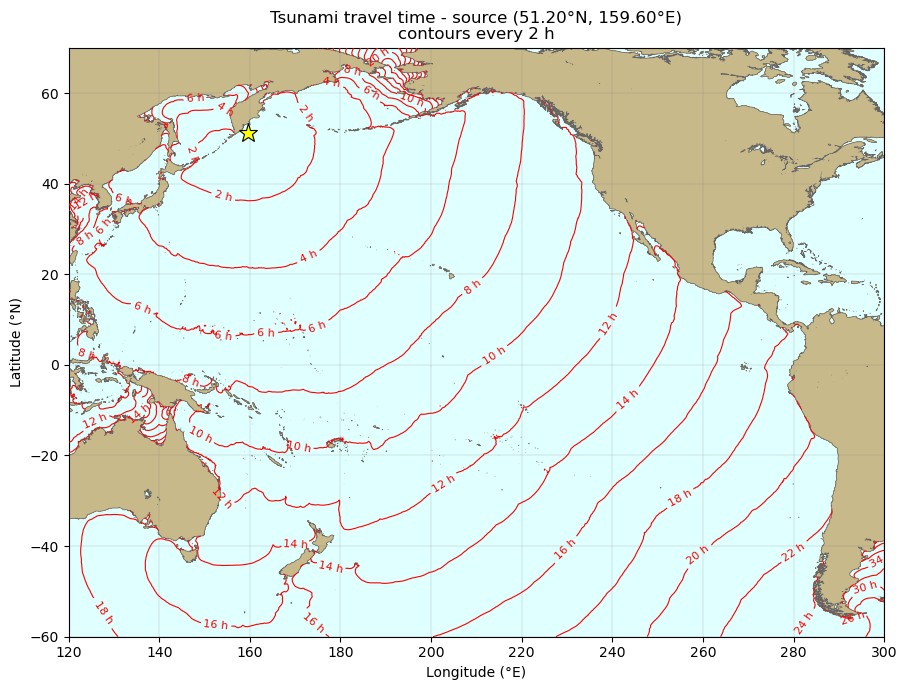

Figure saved into tsunami_travel_time_simple.png


In [6]:
# ── Quick plot: travel-time contours + land, no bathymetry ────────────────
LON2D, LAT2D = np.meshgrid(lon, lat)
travel_time_h = travel_time_min / 60.0
max_h  = float(travel_time_h.max())
levels = np.arange(0, max_h + CONTOUR_INTERVAL_H, CONTOUR_INTERVAL_H)

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_facecolor('lightcyan')
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_aspect('equal')

# Land fill and coastline from GEBCO elevation
land_elev = np.ma.masked_where(elev < 0, elev)
ax.contourf(LON2D, LAT2D, land_elev, levels=1, colors=['#c8b98a'], zorder=1)
ax.contour(LON2D, LAT2D, elev, levels=[0], colors=['#666666'], linewidths=0.5, zorder=2)

# Travel-time isolines
cs = ax.contour(LON2D, LAT2D, travel_time_h, levels=levels,
                colors='red', linewidths=0.8, zorder=3)
ax.clabel(cs, fmt=lambda v: f"{v:.0f} h", fontsize=8, inline=True)

ax.plot(SOURCE_LON, SOURCE_LAT, marker='*', color='yellow', markersize=14,
        markeredgecolor='black', markeredgewidth=0.8, zorder=5, linestyle='none')

ax.grid(linewidth=0.3, color='grey', alpha=0.5)
ax.set_title(
    f"Tsunami travel time - source ({SOURCE_LAT:.2f}°N, {SOURCE_LON:.2f}°E)\n"
    f"contours every {CONTOUR_INTERVAL_H} h", fontsize=12
)
plt.tight_layout()
plt.savefig("tsunami_travel_time_simple.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved into tsunami_travel_time_simple.png")

## 7. Full plot

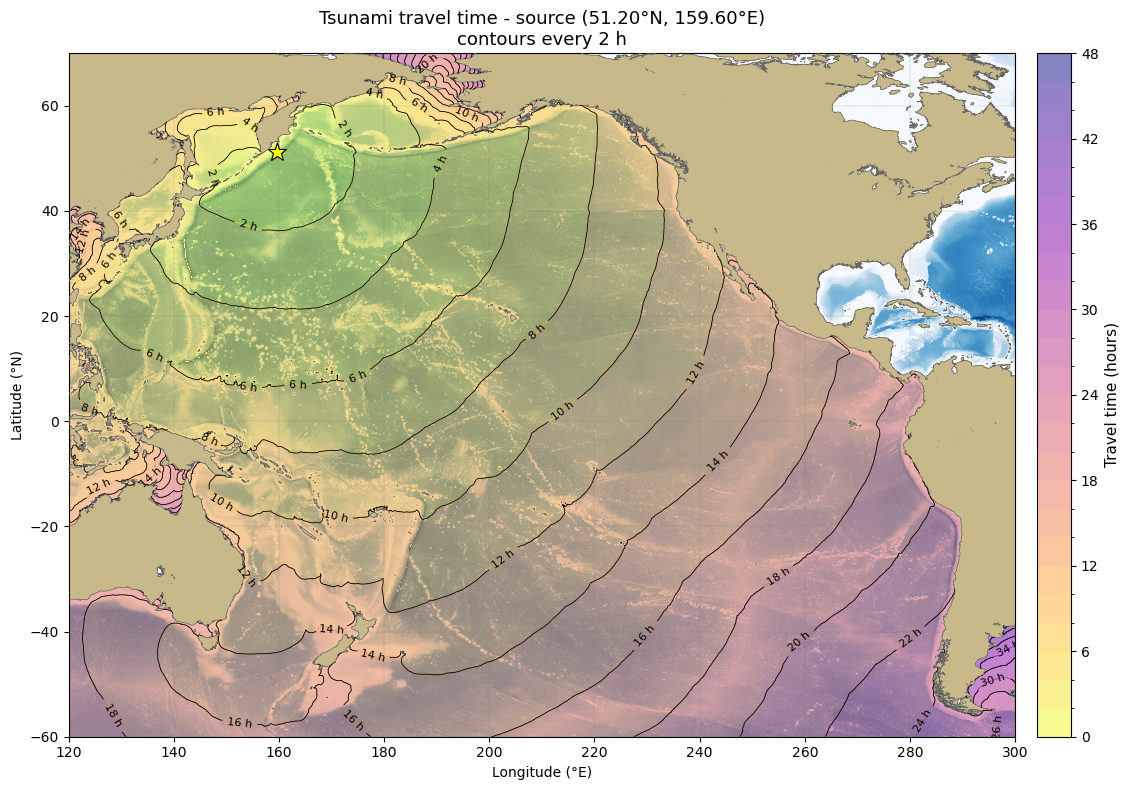

Figure saved into tsunami_travel_time.png


In [7]:
# ── Full plot: travel-time bands over bathymetry ──────────────────────────
LON2D, LAT2D = np.meshgrid(lon, lat)
travel_time_h = travel_time_min / 60.0
max_h  = float(travel_time_h.max())
levels = np.arange(0, max_h + CONTOUR_INTERVAL_H, CONTOUR_INTERVAL_H)

bathy_levels = np.linspace(-8000, 0, 81)
land_color   = "#c8b98a"
tt_cmap      = plt.cm.plasma_r
norm         = mcolors.BoundaryNorm(levels, ncolors=tt_cmap.N)

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_aspect('equal')

# Bathymetry background
ocean_elev = np.ma.masked_where(elev >= 0, elev)
ax.contourf(LON2D, LAT2D, ocean_elev, levels=bathy_levels, cmap='Blues_r', zorder=0)

# Travel-time filled bands
cf = ax.contourf(LON2D, LAT2D, travel_time_h, levels=levels,
                 cmap=tt_cmap, norm=norm, alpha=0.5, zorder=1)

# Land on top
land_elev = np.ma.masked_where(elev < 0, elev)
ax.contourf(LON2D, LAT2D, land_elev, levels=1, colors=[land_color], zorder=2)
ax.contour(LON2D, LAT2D, elev, levels=[0], colors=['#666666'], linewidths=0.5, zorder=3)

# Travel-time isolines
cs = ax.contour(LON2D, LAT2D, travel_time_h, levels=levels,
                colors='k', linewidths=0.6, zorder=4)
ax.clabel(cs, fmt=lambda v: f"{v:.0f} h", fontsize=8, inline=True)

# Source marker
ax.plot(SOURCE_LON, SOURCE_LAT, marker='*', color='yellow', markersize=14,
        markeredgecolor='black', markeredgewidth=0.8, zorder=6, linestyle='none')
# ax.annotate("Source", xy=(SOURCE_LON, SOURCE_LAT),
#             xytext=(SOURCE_LON + 1, SOURCE_LAT + 1),
#             fontsize=9, color='yellow', fontweight='bold',
#             arrowprops=dict(arrowstyle='->', color='yellow', lw=0.8))

# Colourbar
cbar = fig.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, fraction=0.04)
cbar.set_label("Travel time (hours)", fontsize=11)

ax.grid(linewidth=0.3, color='grey', alpha=0.5)
ax.set_title(
    f"Tsunami travel time - source ({SOURCE_LAT:.2f}°N, {SOURCE_LON:.2f}°E)\n"
    f"contours every {CONTOUR_INTERVAL_H} h", fontsize=13
)
plt.tight_layout()
plt.savefig("tsunami_travel_time.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved into tsunami_travel_time.png")

## 7. Arrival times at named locations

In [8]:
print(f"{'Location':<28} {'Travel time':>22}")
print("-" * 52)

# Pre-compute indices of all reachable (unmasked) ocean cells
reachable = ~np.ma.getmaskarray(travel_time_min) & ocean_mask
reach_iy, reach_ix = np.where(reachable)

for name, (tlon, tlat) in TARGETS.items():
    if not (LON_MIN <= tlon <= LON_MAX and LAT_MIN <= tlat <= LAT_MAX):
        print(f"{name:<28} {'outside domain':>22}")
        continue

    ix_t = np.argmin(np.abs(lon - tlon))
    iy_t = np.argmin(np.abs(lat - tlat))

    # Find nearest reachable ocean cell (handles coarse grids closing passages)
    if not reachable[iy_t, ix_t]:
        dist2 = (reach_iy - iy_t)**2 + (reach_ix - ix_t)**2
        nearest = np.argmin(dist2)
        iy_t, ix_t = reach_iy[nearest], reach_ix[nearest]

    tt = travel_time_min[iy_t, ix_t]

    if np.ma.is_masked(tt):
        label = "not reached"
    else:
        h = int(tt) // 60
        m = int(tt) % 60
        label = f"{h} h {m:02d} min  ({tt:.0f} min total)"

    print(f"{name:<28} {label:>22}")

Location                                Travel time
----------------------------------------------------
Tokyo (JP)                   4 h 30 min  (270 min total)
Osaka (JP)                   6 h 10 min  (370 min total)
Sapporo (JP)                 5 h 41 min  (341 min total)
Sendai (JP)                  3 h 53 min  (233 min total)
Sydney (AU)                  13 h 04 min  (784 min total)
Melbourne (AU)               19 h 30 min  (1171 min total)
Brisbane (AU)                13 h 22 min  (802 min total)
Perth (AU)                           outside domain
Auckland (NZ)                15 h 08 min  (908 min total)
New Plymouth (NZ)            14 h 41 min  (881 min total)
Napier (NZ)                  13 h 44 min  (824 min total)
Wellington (NZ)              13 h 46 min  (827 min total)
Christchurch (NZ)            15 h 31 min  (931 min total)
Dunedin (NZ)                 16 h 04 min  (964 min total)
Honolulu (HI)                7 h 11 min  (432 min total)
Hilo (HI)                    7 h 33